### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import plotly.graph_objs as go

from keras.models import Sequential
from keras.layers import LSTM, Dense, Input, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from plotly.subplots import make_subplots
from tensorflow.keras.layers import Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

### Loading Data

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
file_path = '/content/drive/MyDrive/Case Studies/4. Airline Passenger Forecasting/International Airline Passengers.csv'

df = pd.read_csv(file_path)
print(df.head())

     Month  No_passengers_thousands
0  1949-01                      112
1  1949-02                      118
2  1949-03                      132
3  1949-04                      129
4  1949-05                      121


#### Visualization

In [4]:
df=df['No_passengers_thousands']

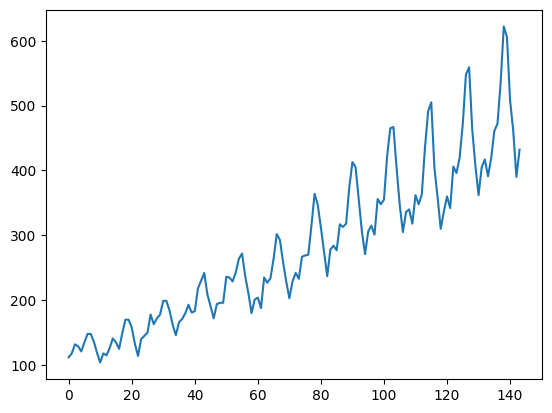

In [5]:
df_log = plt.plot(df)
plt.show(df_log)

In [6]:
def check_stationarity(timeseries):

    # Calculate rolling statistics
    rolling_mean = timeseries.rolling(window=12).mean()
    rolling_std = timeseries.rolling(window=12).std()

    # Plot rolling statistics
    plt.figure(figsize=(10, 6))
    plt.plot(timeseries, color='blue', label='Original')
    plt.plot(rolling_mean, color='red', label='Rolling Mean')
    plt.plot(rolling_std, color='black', label='Rolling Std')
    plt.legend(loc='best')
    plt.title('Rolling Mean & Standard Deviation')
    plt.show()

    # Perform Dickey-Fuller test
    print('Dickey-Fuller Test Results:')
    df_test = adfuller(timeseries)
    df_output = pd.Series(df_test[:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in df_test[4].items():
        df_output[f'Critical Value ({key})'] = value
    print(df_output)

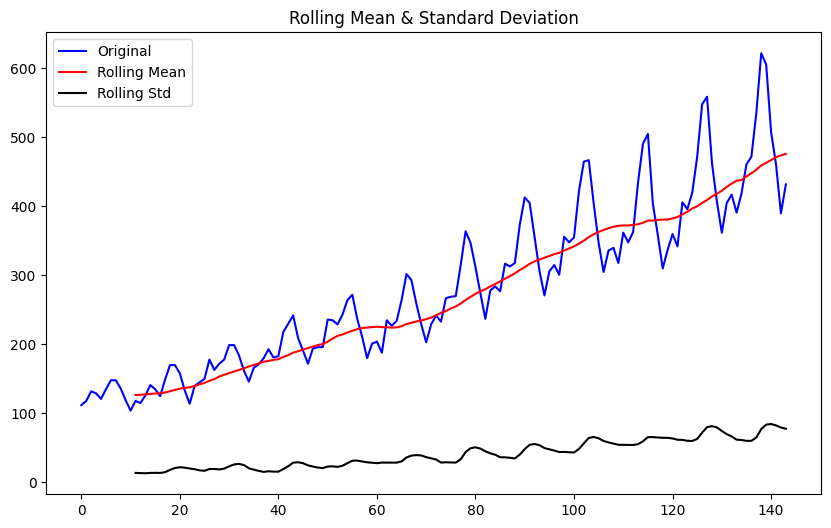

Dickey-Fuller Test Results:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


In [7]:
check_stationarity(df)

In [8]:
df = df.to_frame()
print(df.columns)

Index(['No_passengers_thousands'], dtype='object')


In [9]:
### Creation of Date column with monthly ending frequency
df['Date'] = pd.date_range(start='1949-01-01', periods=len(df), freq='ME')

In [10]:
decomposition_result = seasonal_decompose(df["No_passengers_thousands"], model="additive", period=12)

fig = make_subplots(rows=4, cols=1, subplot_titles=("Original Series", "Trend Component", "Seasonal Component", "Residuals"))

fig.add_trace(go.Scatter(x=df["Date"], y=decomposition_result.observed, mode="lines", name="Original", line=dict(color="darkblue")), row=1, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=decomposition_result.trend, mode="lines", name="Trend", line=dict(color="green")), row=2, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=decomposition_result.seasonal, mode="lines", name="Seasonality", line=dict(color="purple")), row=3, col=1)
fig.add_trace(go.Scatter(x=df["Date"], y=decomposition_result.resid, mode="lines", name="Residuals", line=dict(color="orange")), row=4, col=1)

fig.update_layout(title="Decomposition of Time Series", height=900, showlegend=False, plot_bgcolor="whitesmoke")

animation_frames = []
for i in range(len(df)):
    frame = go.Frame(data=[go.Scatter(x=df["Date"][:i+1], y=decomposition_result.observed[:i+1], mode="lines", name="Original", line=dict(color="darkblue")),
                            go.Scatter(x=df["Date"][:i+1], y=decomposition_result.trend[:i+1], mode="lines", name="Trend", line=dict(color="green")),
                            go.Scatter(x=df["Date"][:i+1], y=decomposition_result.seasonal[:i+1], mode="lines", name="Seasonality", line=dict(color="purple")),
                            go.Scatter(x=df["Date"][:i+1], y=decomposition_result.resid[:i+1], mode="lines", name="Residuals", line=dict(color="orange"))],
                      traces=[0, 1, 2, 3])
    animation_frames.append(frame)

fig.frames = animation_frames

fig.update_layout(updatemenus=[dict(type="buttons", showactive=False,
                                    buttons=[dict(label="Play", method="animate", args=[None, {"frame": {"duration": 400, "redraw": True}, "fromcurrent": True, "mode": "immediate"}]),
                                             dict(label="Pause", method="animate", args=[[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}])])])

fig.show()

In [11]:
### Reducing the impact of outliers using logarithmic values
df_log = np.log(df["No_passengers_thousands"])
df_log_diff = df_log - df_log.shift()

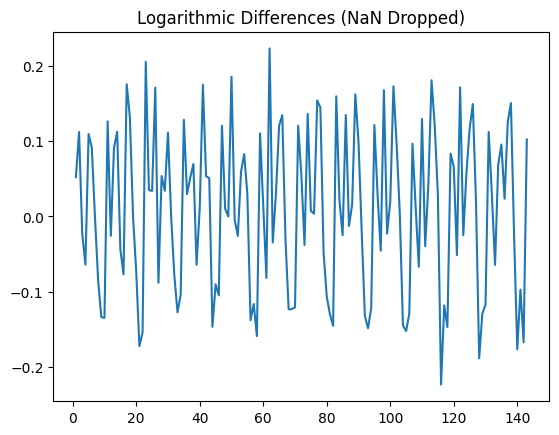

In [12]:
### Visualization of log differences
plt.plot(df_log_diff.dropna())
plt.title("Logarithmic Differences (NaN Dropped)")
plt.show()

In [13]:
df_log_diff = df_log_diff.dropna()

### Data Preprocessing

In [14]:
print(df.columns)

Index(['No_passengers_thousands', 'Date'], dtype='object')


In [15]:
#df = df.drop(columns=['Date'])

In [16]:
#df = np.array(df).reshape(-1,1)### Converting to array
#df

In [35]:
scaler = MinMaxScaler()
df_log = scaler.fit_transform(df_log.values.reshape(-1, 1))

### Train-Test Split

In [37]:
### Splitting on log transformned data
train = df_log[0:100]
test = df_log[100:]

In [38]:
def get_data(df, steps):
    dataX = []
    dataY = []
    for i in range(len(df)-steps-1):
        a = df[i:(i+steps), 0]
        dataX.append(a)
        dataY.append(df[i+steps, 0])
    return np.array(dataX), np.array(dataY)

In [39]:
steps = 12

In [40]:
X_train, y_train = get_data(train, steps)
X_test, y_test = get_data(test, steps)

In [42]:
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

#### Define LSTM Model

In [44]:
from tensorflow.keras import regularizers
LSTMmodel = Sequential()
LSTMmodel.add(Input(shape=(1, steps)))

# Reduced units + added L2 regularization
LSTMmodel.add(LSTM(32,
                   kernel_regularizer=regularizers.l2(0.01),
                   recurrent_regularizer=regularizers.l2(0.01)))

#  Dropout layer
LSTMmodel.add(Dropout(0.3))

# Simplified Dense layer
LSTMmodel.add(Dense(16, activation="relu"))
LSTMmodel.add(Dense(1))

LSTMmodel.compile(loss='mean_squared_error', optimizer='adam')

In [45]:
LSTMmodel.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         5,760 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,305 (24.63 KB)

 Trainable params: 6,305 (24.63 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=0.0001)

# Fitting the model against 200 epochs
history = LSTMmodel.fit(X_train, y_train,
          epochs=200,
          batch_size=2,
          validation_split=0.1,
          callbacks=[early_stop, reduce_lr],
          verbose=1)

Epoch 1/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0041 - val_loss: 0.0042 - learning_rate: 1.0000e-04
Epoch 2/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0036 - val_loss: 0.0038 - learning_rate: 1.0000e-04
Epoch 3/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0037 - val_loss: 0.0039 - learning_rate: 1.0000e-04
Epoch 4/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0045 - val_loss: 0.0041 - learning_rate: 1.0000e-04
Epoch 5/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0036 - val_loss: 0.0038 - learning_rate: 1.0000e-04
Epoch 6/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0037 - val_loss: 0.0039 - learning_rate: 1.0000e-04
Epoch 7/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - val_loss: 0.0040 - learning_rate: 1.0000e-04
Epoch 8/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - val_loss: 0.0040 - learning_rate: 1.0000e-04
Epoch 9/200
39/39 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0039 - val_loss: 0.0046 - learnin

In [62]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error
import numpy as np

def evaluate_model(X, y_true_scaled, label):
    # 1. Get Predictions (0-1 scaled range)
    y_pred_scaled = LSTMmodel.predict(X)
    y_true_scaled = y_true_scaled.reshape(-1, 1)

    # 2. Reverse MinMaxScaler (Back to Log Scale)
    y_pred_log = scaler.inverse_transform(y_pred_scaled)
    y_true_log = scaler.inverse_transform(y_true_scaled)

    # 3. Reverse Log (Back to Passenger Counts)
    y_pred_final = np.exp(y_pred_log)
    y_true_final = np.exp(y_true_log)

    # 4. Calculate Metrics
    mse = mean_squared_error(y_true_final, y_pred_final)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true_final, y_pred_final)
    mape = mean_absolute_percentage_error(y_true_final, y_pred_final) * 100
    r2 = r2_score(y_true_final, y_pred_final)

    print(f"--- {label} Metrics (Original Scale) ---")
    print(f"MAE:   {mae:.2f}")
    print(f"RMSE:  {rmse:.2f}")
    print(f"MAPE:  {mape:.2f}%") # Added MAPE
    print(f"R2:    {r2:.4f}\n")

    return y_true_final, y_pred_final

# Run evaluation for both sets
y_train_true, y_train_pred = evaluate_model(X_train, y_train, "TRAIN")
y_test_true, y_test_pred = evaluate_model(X_test, y_test, "TEST")

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
--- TRAIN Metrics (Original Scale) ---
MAE:   11.75
RMSE:  15.28
MAPE:  5.18%
R2:    0.9510

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
--- TEST Metrics (Original Scale) ---
MAE:   32.44
RMSE:  41.10
MAPE:  6.95%
R2:    0.7178



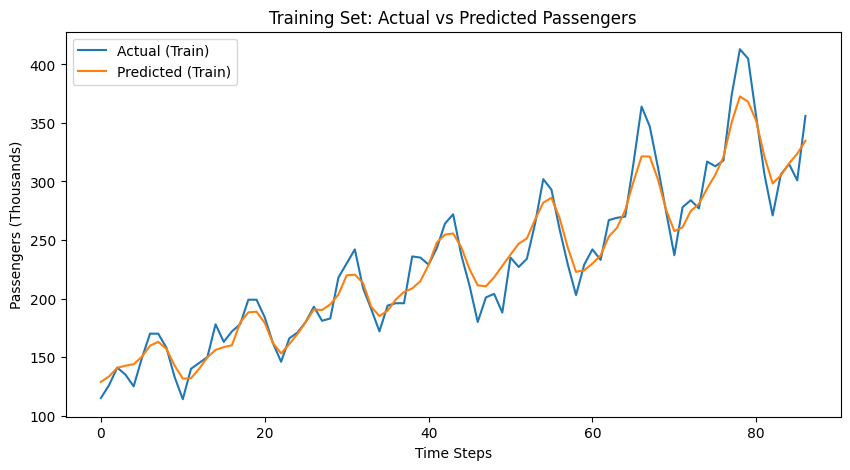

In [59]:
# Visualization of Train Performance
plt.figure(figsize=(10, 5))
plt.plot(y_train_true, label='Actual (Train)')
plt.plot(y_train_pred, label='Predicted (Train)')
plt.title('Train Set: Actual vs Predicted Passengers')
plt.xlabel('Time Steps')
plt.ylabel('Passengers (Thousands)')
plt.legend()
plt.show()


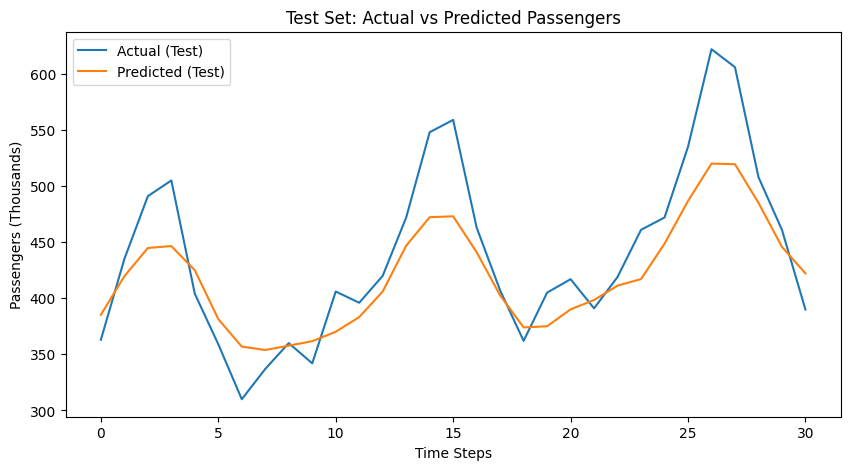

In [61]:
# 5. Visualization of Test Performance
plt.figure(figsize=(10, 5))
plt.plot(y_test_true, label='Actual (Test)')
plt.plot(y_test_pred, label='Predicted (Test)')
plt.title('Test Set: Actual vs Predicted Passengers')
plt.xlabel('Time Steps')
plt.ylabel('Passengers (Thousands)')
plt.legend()
plt.show()